<div style="background:linear-gradient(135deg,#0a1628 0%,#1a2f4e 100%);
border:2px solid #c9a84c;border-radius:12px;padding:2rem 2.5rem;margin-bottom:1rem;">
<h1 style="color:#c9a84c;font-size:1.9rem;margin:0 0 0.4rem;">
NPSC2002: Space Exploration</h1>
<h2 style="color:#e8e8e8;font-size:1.3rem;margin:0 0 1rem;font-weight:normal;">
Week 9: Remote Sensing and Earth Observation</h2>
<p style="color:#a0b0c8;margin:0;font-size:0.95rem;">
Real Sentinel-2 imagery from Digital Earth Australia
&nbsp;|&nbsp; Darling Scarp, Perth Hills, WA
&nbsp;|&nbsp; NASA FIRMS active fire monitoring
</p>
</div>

## Introduction

Every day, hundreds of satellites image the Earth's surface. These are not cameras in the
conventional sense: rather than capturing a photograph, they measure the intensity of
electromagnetic radiation reflected from the ground across multiple wavelength ranges
simultaneously. The resulting data, called **multispectral imagery**, allows scientists to
distinguish land cover types, monitor vegetation health, detect fires, map floods, and
track environmental changes invisible to the naked eye.

This workshop uses **real Sentinel-2 satellite imagery** of the Perth Hills, sourced from
**Digital Earth Australia (DEA)** - Geoscience Australia's free, open archive of
satellite imagery covering the entire Australian continent. DEA is a world-leading
government EO programme and a direct case study for this course.

The scientific focus is the **2021 Wooroloo bushfire**: the worst bushfire in Western
Australia in 30 years. It ignited on 1 February 2021 and burned 8,400 hectares of
jarrah forest on the Darling Scarp over four days, destroying 86 homes. You will work
with real imagery captured before and after the fire, calculate the same fire severity
indices used operationally by DFES and Parks and Wildlife, and pull live fire hotspot
data from NASA's satellite monitoring system.

**By the end of this workshop you should be able to:**
- Load and display real multispectral satellite imagery in Python
- Explain what each spectral band measures and why multiple bands are needed
- Calculate and interpret NDVI, NDWI, and NBR from real data
- Produce a classified fire severity map using dNBR
- Retrieve and map live active fire hotspot data from NASA FIRMS


## Setup

No extra libraries are needed beyond the standard Colab environment.
Run the cell below once to import everything and configure the plot style.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import pandas as pd
import requests, json
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Course palette
NAVY  = '#0a1628'
GOLD  = '#c9a84c'
LIGHT = '#e8e8e8'
DIM   = '#a0b0c8'

plt.rcParams.update({
    'figure.facecolor':  NAVY,
    'axes.facecolor':    NAVY,
    'axes.edgecolor':    GOLD,
    'axes.labelcolor':   GOLD,
    'axes.titlecolor':   GOLD,
    'text.color':        LIGHT,
    'xtick.color':       LIGHT,
    'ytick.color':       LIGHT,
    'grid.color':        '#1e3050',
    'grid.alpha':        0.4,
    'font.family':       'sans-serif',
    'savefig.facecolor': NAVY,
})

def gamma(arr, g=2.2):
    """Gamma-correct a linear reflectance array for screen display."""
    return np.clip(arr, 0, 1) ** (1.0 / g)

def stretch(arr, lo=2, hi=98):
    """Percentile-stretch an array, ignoring nodata and saturated pixels."""
    valid = arr[(arr > 0.0001) & (arr < 1.0)]
    p_lo = np.percentile(valid, lo) if len(valid) > 0 else 0
    p_hi = np.percentile(valid, hi) if len(valid) > 0 else 1
    return np.clip((arr - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)

print("Setup complete.")


Setup complete.


## Loading the satellite data

The imagery was sourced from **Digital Earth Australia** (Geoscience Australia) and
pre-processed into a compact format for this workshop. Both scenes cover the same
14 x 15 km study area over the Darling Scarp at 20 m resolution.

The data is real Sentinel-2 surface reflectance (NBART: Nadir BRDF-Adjusted Reflectance
from Terrain correction). Values have been scaled to the range 0-1 where 1 represents
100% reflectance.

**Update the URL below** to point to your course GitHub repository after running the
data prep notebook.


In [4]:
# ── Update this URL to your course GitHub ────────────────────────────────────
DATA_BASE_URL = "https://raw.githubusercontent.com/hdevillepoix/NPSC2002-workshops/main/data/EO/"

def load_npz(filename):
    """Download a compressed numpy file from GitHub and return the array."""
    url = DATA_BASE_URL + filename
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return np.load(BytesIO(resp.content))['data'].astype(np.float32)

def load_json(filename):
    url = DATA_BASE_URL + filename
    return requests.get(url, timeout=10).json()

print("Downloading pre-fire scene...")
arr_pre  = load_npz("wooroloo_pre.npz")

print("Downloading post-fire scene...")
arr_post = load_npz("wooroloo_post.npz")

print("Loading metadata...")
meta = load_json("wooroloo_meta.json")

# Align extents (may differ by 1-2 edge pixels)
h = min(arr_pre.shape[1], arr_post.shape[1])
w = min(arr_pre.shape[2], arr_post.shape[2])
arr_pre  = arr_pre[:,  :h, :w]
arr_post = arr_post[:, :h, :w]

BAND_LABELS = meta['bands']
WAVELENGTHS = meta['wavelengths_nm']
DATE_PRE    = meta['date_pre']
DATE_POST   = meta['date_post']

print(f"\nPre-fire:   {DATE_PRE}  {arr_pre.shape}")
print(f"Post-fire:  {DATE_POST}  {arr_post.shape}")
print(f"Pixel size: {meta['resolution_m']} m  |  Area: {arr_pre.shape[1]*20/1000:.0f} x {arr_pre.shape[2]*20/1000:.0f} km")
print(f"Source:     {meta['source']}")


Loading metadata...

Pre-fire:   2021-01-31  (6, 782, 716)
Post-fire:  2021-03-17  (6, 782, 716)
Pixel size: 20 m  |  Area: 16 x 14 km
Source:     Digital Earth Australia, Sentinel-2 NBART ARD, CC-BY 4.0


---
## Section 1: How Satellites See the World

### From pixels to light

A satellite sensor measures how much electromagnetic radiation bounces back from the
surface at specific wavelength windows. Each measurement becomes a pixel value in a
particular **band**. Stack six bands over the same area and you have a six-dimensional
description of every square metre of ground.

Different materials interact with light very differently depending on wavelength:

- **Chlorophyll** in plant leaves strongly absorbs red light (used for photosynthesis)
  but reflects near-infrared (NIR) strongly. The mesophyll cell structure scatters NIR
  rather than absorbing it, so a healthy canopy reflects 40-60% of incoming NIR energy.
- **Liquid water** absorbs essentially all radiation beyond about 700 nm. A pixel of
  open water shows near-zero values in every infrared band.
- **Iron oxides** in laterite soils produce characteristic absorption features in
  the shortwave infrared and high reflectance in the red, giving the Darling Scarp
  its distinctive colour.

### True colour vs false colour

A **true-colour composite** (R=B04, G=B03, B=B02) approximates natural appearance.

A **false-colour composite** (R=B08 NIR, G=B04, B=B03) puts NIR in the red channel:
healthy vegetation appears bright red because it reflects so strongly there.

| Band | Wavelength | Sentinel-2 band | What it detects |
|------|-----------|----------------|----------------|
| Blue | 490 nm | B02 | Water depth, aerosol scattering |
| Green | 560 nm | B03 | Vegetation vigour, turbidity |
| Red | 665 nm | B04 | Chlorophyll absorption |
| NIR | 842 nm | B08 | Vegetation biomass, canopy moisture |
| SWIR1 | 1610 nm | B11 | Soil moisture, burn scars |
| SWIR2 | 2190 nm | B12 | Mineral mapping, fire severity |


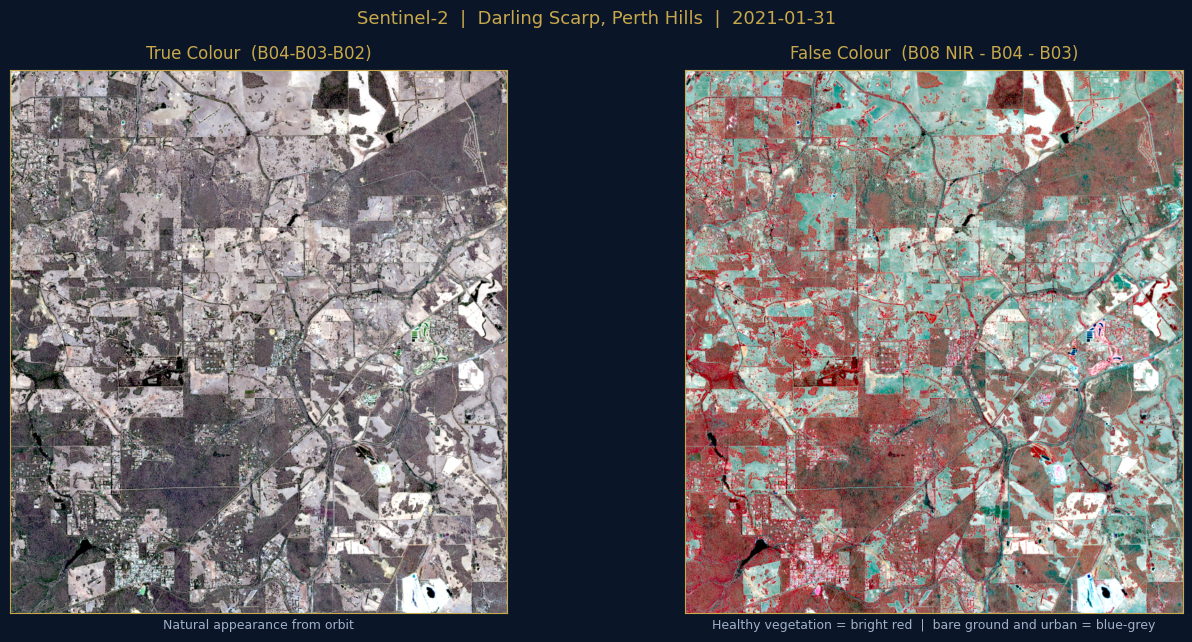

In [5]:
# Indices: B02=0  B03=1  B04=2  B08=3  B11=4  B12=5
rgb_true  = np.dstack([gamma(stretch(arr_pre[i])) for i in [2, 1, 0]])   # R=B04 G=B03 B=B02
rgb_false = np.dstack([gamma(stretch(arr_pre[i])) for i in [3, 2, 1]])   # R=B08 G=B04 B=B03

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle(f'Sentinel-2  |  Darling Scarp, Perth Hills  |  {DATE_PRE}',
             color=GOLD, fontsize=13)

for ax, img, title, note in zip(
    axes,
    [rgb_true, rgb_false],
    ['True Colour  (B04-B03-B02)', 'False Colour  (B08 NIR - B04 - B03)'],
    ['Natural appearance from orbit',
     'Healthy vegetation = bright red  |  bare ground and urban = blue-grey']
):
    ax.imshow(img, origin='upper', interpolation='bilinear')
    ax.set_title(title, color=GOLD, pad=8)
    ax.set_xlabel(note, color=DIM, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


### Spectral signatures

Each land cover type leaves a distinctive fingerprint across the six bands. The cell
below samples pixel values at four known locations in the study area and plots their
reflectance across the spectrum.

Inspect the true-colour and false-colour images above to confirm what each location looks
like before interpreting the signatures.

| Sample site | Location | Expected appearance |
|------------|---------|-------------------|
| Jarrah forest | Walyunga NP, upper Scarp | Dark green in true colour, bright red in false colour |
| Cleared farmland | Avon Valley floor, east of Scarp | Pale/straw-coloured |
| Wooroloo (urban) | Wooroloo townsite | Grey-white rooftops |
| Laterite scrub | Scarp escarpment | Red-brown, ironstone soils |


Extracted spectra (surface reflectance):
  Jarrah forest: ['0.041', '0.061', '0.080', '0.224', '0.234', '0.143']
  Cleared farmland: ['0.036', '0.052', '0.068', '0.202', '0.204', '0.128']
  Wooroloo (urban): ['0.033', '0.050', '0.063', '0.241', '0.195', '0.108']
  Laterite scrub: ['0.056', '0.083', '0.113', '0.240', '0.274', '0.182']


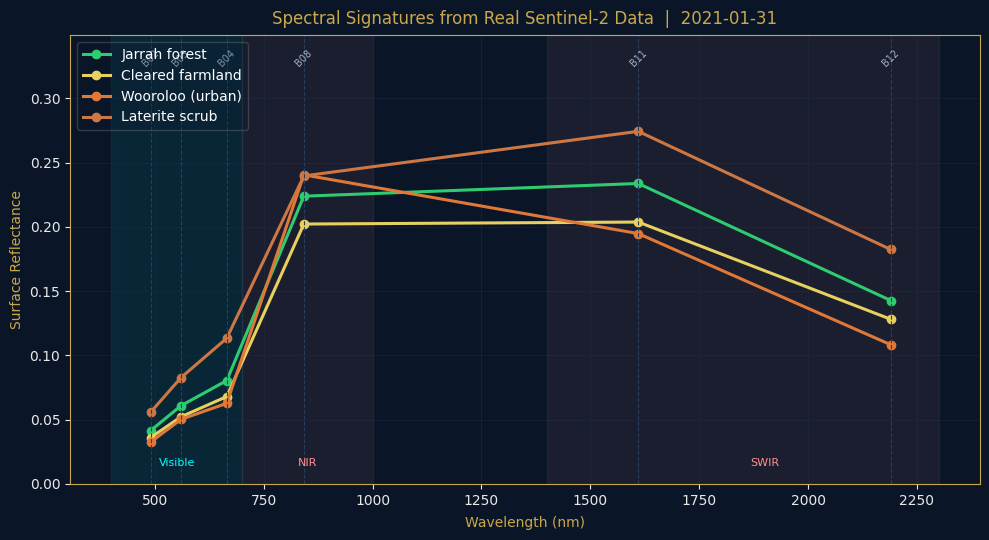

In [6]:
# Sample pixel coordinates as fractional position in the array
# (calibrated to the study area bounding box)
# Format: (row_fraction, col_fraction) where 0,0 = top-left

H, W = arr_pre.shape[1], arr_pre.shape[2]

SAMPLE_SITES = {
    'Jarrah forest':    (0.22, 0.20),   # upper Scarp, west side
    'Cleared farmland': (0.70, 0.80),   # Avon Valley floor, east
    'Wooroloo (urban)': (0.72, 0.52),   # Wooroloo townsite
    'Laterite scrub':   (0.35, 0.12),   # scarp escarpment
}
LC_COLOURS = ['#2ecc71', '#e8d060', '#e07838', '#cc7744']

def sample_patch(arr, r_frac, c_frac, radius=4):
    """Return mean spectrum from a small patch around a fractional position."""
    r = int(r_frac * H)
    c = int(c_frac * W)
    r0, r1 = max(0, r-radius), min(H, r+radius)
    c0, c1 = max(0, c-radius), min(W, c+radius)
    return arr[:, r0:r1, c0:c1].mean(axis=(1, 2))

spectra = {name: sample_patch(arr_pre, rf, cf)
           for name, (rf, cf) in SAMPLE_SITES.items()}

print("Extracted spectra (surface reflectance):")
for name, sig in spectra.items():
    print(f"  {name}: {[f'{v:.3f}' for v in sig]}")

fig, ax = plt.subplots(figsize=(10, 5.5))
for (name, sig), col in zip(spectra.items(), LC_COLOURS):
    ax.plot(WAVELENGTHS, sig, 'o-', color=col, label=name, linewidth=2.2, markersize=6)

ax.axvspan(400,  700,  alpha=0.07, color='cyan')
ax.axvspan(700,  1000, alpha=0.07, color='#ff8888')
ax.axvspan(1400, 2300, alpha=0.07, color='#ff8888')

ymax = max(sig.max() for sig in spectra.values()) * 1.2 + 0.02
for wl, bl in zip(WAVELENGTHS, BAND_LABELS):
    ax.axvline(wl, color='#2a3d5a', lw=0.8, ls='--')
    ax.text(wl, ymax * 0.93, bl.split()[0], ha='center', fontsize=7, color=DIM, rotation=45)

ax.text(550,  ymax*0.04, 'Visible', color='cyan',    fontsize=8, ha='center')
ax.text(850,  ymax*0.04, 'NIR',     color='#ff9090', fontsize=8, ha='center')
ax.text(1900, ymax*0.04, 'SWIR',    color='#ff9090', fontsize=8, ha='center')

ax.set_xlabel('Wavelength (nm)', labelpad=6)
ax.set_ylabel('Surface Reflectance')
ax.set_title(f'Spectral Signatures from Real Sentinel-2 Data  |  {DATE_PRE}', pad=8)
ax.set_ylim(0, ymax)
ax.legend(framealpha=0.2, labelcolor='white', loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()


### Discussion 1

1. The NIR band (842 nm) shows a large difference between jarrah forest and the other
   land cover types. Why does healthy forest reflect so strongly in the near-infrared?
   What is happening at the cellular level inside the leaf that causes this?

2. Laterite scrub has high red reflectance compared to forest. How does this show up
   in the true-colour composite? What geological process produces iron-oxide-rich soils
   on the Darling Scarp?

3. Looking at the cleared farmland signature: how does it compare to jarrah forest
   across all six bands? What does this pattern tell you about the state of vegetation
   on this farmland at the time the image was captured?


1. Jarrah leaves contain a spongy mesophyll layer, loosely arranged cells with air spaces between them which scatters NIR radiation and causes high reflectance.

2. In the true-colour composite, where red, green and blue are mapped to their respective channels, laterite appears bright red or reddish-orange due to the iron oxides present. These oxides are produced by laterisation, where intense weathering causes soluble materials like silica and organic matter to be leached out, leaving behind residual iron oxides.

3. Cleared farmland will show much lower reflectance in the NIR band and higher reflectance in the red band compared to jarrah forest. The pattern indicates that the farmland lacks healthy, dense vegetation that is able to scatter NIR light, and consists of bare soil, crop stubble and sparse vegetation.

---
## Section 2: Spectral Indices

### Turning band ratios into maps

Rather than looking at individual bands, analysts combine bands into **spectral indices**:
normalised ratios that amplify contrast between specific surface properties.
Two bands are chosen: one where the target material reflects strongly, one where it
absorbs. Dividing their difference by their sum produces a value between -1 and +1
that is less sensitive to illumination angle and atmospheric variation than raw bands.

### NDVI: Normalised Difference Vegetation Index

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

| NDVI | Typical interpretation |
|------|----------------------|
| > 0.6 | Dense, healthy vegetation |
| 0.3 to 0.6 | Moderate or sparse vegetation |
| 0.1 to 0.3 | Dry grass, degraded vegetation |
| -0.1 to 0.1 | Bare soil, urban surfaces |
| < -0.1 | Water, burned areas |

DEA generates national NDVI composites every 16 days from Landsat, archived back to 1988.

### NDWI: Normalised Difference Water Index

$$\text{NDWI} = \frac{\text{Green} - \text{NIR}}{\text{Green} + \text{NIR}}$$

Water bodies return positive values; all vegetation and soil returns negative.
Used operationally in WA for flood extent mapping after rainfall events.


In [ ]:
NIR = arr_pre[3].astype(float)
Red = arr_pre[2].astype(float)
Grn = arr_pre[1].astype(float)

ndvi = (NIR - Red) / (NIR + Red + 1e-9)
ndwi = (Grn - NIR) / (Grn + NIR + 1e-9)

ndvi_cmap = LinearSegmentedColormap.from_list(
    'ndvi', ['#8B2020','#CC5500','#DAA520','#9ACD32','#228B22'], N=256)
ndwi_cmap = LinearSegmentedColormap.from_list(
    'ndwi', ['#8B4513','#D2B48C','#F5F5DC','#87CEEB','#0047AB'], N=256)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(f'Spectral Indices  |  Darling Scarp, Perth Hills  |  {DATE_PRE}',
             color=GOLD, fontsize=13)

axes[0].imshow(rgb_true, origin='upper', interpolation='bilinear')
axes[0].set_title('True Colour (reference)', color=GOLD, pad=6)

im1 = axes[1].imshow(ndvi, cmap=ndvi_cmap, vmin=-0.3, vmax=0.85,
                     origin='upper', interpolation='bilinear')
axes[1].set_title('NDVI', color=GOLD, pad=6)
cb1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb1.set_label('NDVI', color=GOLD)
plt.setp(cb1.ax.yaxis.get_ticklabels(), color=LIGHT)

im2 = axes[2].imshow(ndwi, cmap=ndwi_cmap, vmin=-0.7, vmax=0.5,
                     origin='upper', interpolation='bilinear')
axes[2].set_title('NDWI', color=GOLD, pad=6)
cb2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cb2.set_label('NDWI', color=GOLD)
plt.setp(cb2.ax.yaxis.get_ticklabels(), color=LIGHT)

for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"NDVI  mean={ndvi.mean():.3f}  min={ndvi.min():.3f}  max={ndvi.max():.3f}")
print(f"NDWI  mean={ndwi.mean():.3f}  min={ndwi.min():.3f}  max={ndwi.max():.3f}")


### Discussion 2

1. Look at the NDVI map. Is vegetation health uniform across the forested area, or does
   it vary? Suggest two physical or ecological factors that could produce spatial
   variation in NDVI within a single jarrah forest.

2. Urban impervious surfaces (roads, rooftops, carparks) sometimes return near-zero or
   slightly positive NDWI values, close to what water bodies show. What spectral
   property causes this, and how would you distinguish them if you needed to?

3. Digital Earth Australia publishes a 35-year NDVI record for every point in Australia.
   Name a specific research question relevant to south-west WA that could only be
   answered with a multi-decade time series, not a single image.


---
## Section 3: The Wooroloo Fire  -  Change Detection with dNBR

### Before and after

One of the most powerful applications of satellite EO is detecting change between two
acquisitions of the same area. Same sensor, same viewing geometry, different date:
any difference in pixel values reflects a real change in the landscape.

On **1 February 2021**, a fire ignited near Wooroloo in the Perth Hills and burned for
four days, driven by extreme northeast winds and temperatures above 44 degrees Celsius.
It was Western Australia's worst bushfire in 30 years: 8,400 hectares of jarrah and
marri forest burned, 86 homes were destroyed, and several lives were lost.

Sentinel-2 imagery from before and after the fire was used by DFES, Parks and Wildlife,
and insurance agencies to map the burned extent and assess damage severity.

### The Normalised Burn Ratio (NBR)

For fire mapping, NDVI is not the optimal index. The **Normalised Burn Ratio (NBR)**
uses SWIR2 (2190 nm) instead of Red:

$$\text{NBR} = \frac{\text{NIR} - \text{SWIR2}}{\text{NIR} + \text{SWIR2}}$$

Fire destroys canopy (collapsing NIR reflectance) while charcoal and ash on the ground
surface raise SWIR2. This pushes NBR from positive (healthy vegetation) toward strongly
negative (burned area).

The change between pre-fire and post-fire NBR is **dNBR** (differenced NBR):

$$\text{dNBR} = \text{NBR}_{\text{pre}} - \text{NBR}_{\text{post}}$$

High positive dNBR indicates severe burning. This is the standard metric used by Parks
Australia, the USGS, and DFES for post-fire damage assessment.

| dNBR | Fire severity class |
|------|-------------------|
| < 0.10 | Unburned |
| 0.10 to 0.27 | Low severity |
| 0.27 to 0.44 | Moderate-low |
| 0.44 to 0.66 | Moderate-high |
| > 0.66 | High severity |


In [ ]:
def calc_nbr(arr):
    nir, swir2 = arr[3].astype(float), arr[5].astype(float)
    return (nir - swir2) / (nir + swir2 + 1e-9)

nbr_pre  = calc_nbr(arr_pre)
nbr_post = calc_nbr(arr_post)
dnbr     = nbr_pre - nbr_post

sev_bounds  = [-9, 0.10, 0.27, 0.44, 0.66, 9]
sev_labels  = ['Unburned','Low','Moderate-Low','Moderate-High','High Severity']
sev_colours = ['#2a6e2a','#aacc44','#f5c518','#e87020','#cc2020']
sev_cmap    = mcolors.ListedColormap(sev_colours)
sev_norm    = BoundaryNorm(sev_bounds, sev_cmap.N)
sev_map     = np.digitize(dnbr, sev_bounds[1:-1])

px_ha   = (20 * 20) / 10000
burned  = np.sum(sev_map >= 1) * px_ha
high    = np.sum(sev_map == 4) * px_ha
print(f"Estimated burned area (dNBR > 0.10):  {burned:,.0f} ha")
print(f"High-severity area (dNBR > 0.66):     {high:,.0f} ha")
print(f"Official Wooroloo fire extent:         ~8,400 ha")

rgb_post_true = np.dstack([gamma(stretch(arr_post[i])) for i in [2,1,0]])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Wooroloo Bushfire  |  Darling Scarp, Perth Hills, WA  |  February 2021',
             color=GOLD, fontsize=14)

panels = [
    (axes[0,0], rgb_true,       f'True Colour  Pre-fire  {DATE_PRE}',  None, None),
    (axes[0,1], rgb_post_true,  f'True Colour  Post-fire  {DATE_POST}', None, None),
    (axes[0,2], nbr_pre,        f'NBR  Pre-fire  {DATE_PRE}',  'RdYlGn', (-0.5, 0.8)),
    (axes[1,0], nbr_post,       f'NBR  Post-fire  {DATE_POST}','RdYlGn', (-0.5, 0.8)),
    (axes[1,1], dnbr,           'dNBR  (pre minus post)',       'RdBu_r', (-0.5, 1.0)),
    (axes[1,2], None,           'Fire Severity Classification', None, None),
]

for ax, img, title, cmap, clim in panels:
    if img is not None:
        if cmap:
            im = ax.imshow(img, cmap=cmap, vmin=clim[0], vmax=clim[1],
                           origin='upper', interpolation='bilinear')
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            plt.setp(cb.ax.yaxis.get_ticklabels(), color=LIGHT)
        else:
            ax.imshow(img, origin='upper', interpolation='bilinear')
    else:
        ax.imshow(sev_map, cmap=sev_cmap, vmin=0, vmax=4,
                  origin='upper', interpolation='nearest')
        patches = [mpatches.Patch(color=c, label=l)
                   for c, l in zip(sev_colours, sev_labels)]
        ax.legend(handles=patches, loc='lower right', framealpha=0.5,
                  fontsize=8, labelcolor='white')
    ax.set_title(title, color=GOLD, pad=6, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


### Discussion 3

1. Compare the pre-fire and post-fire NBR maps. Using the spectral logic from Section 1,
   explain what has physically changed on the ground in the high-severity zone to produce
   the large drop in NBR.

2. The estimated burned area from dNBR will not exactly match the official 8,400 ha
   figure. Give one reason related to the satellite data itself, and one related to the
   dNBR threshold, that could explain a discrepancy in either direction.

3. Some pixels in the severity map may appear as "burned" in areas that were never near
   the fire. Why might dNBR produce false detections over water bodies or dense urban
   areas? How would an analyst filter them out before reporting the final burned extent?


---
## Section 4: Fire from Space in Real Time

### MODIS and VIIRS active fire detection

The Sentinel-2 imagery we have worked with is a **passive optical sensor**: it measures
reflected sunlight. It is ideal for detailed land cover mapping and post-fire assessment,
but has two limitations for operational emergency response during an active fire:

1. It cannot see through **cloud or thick smoke**.
2. It revisits each location only **every 5 days** (two satellites combined).

For detecting fires as they burn, a different approach is used. NASA's MODIS sensor
(aboard Terra and Aqua) and VIIRS sensor (aboard Suomi-NPP and NOAA-20) measure
**thermal emission** in the mid-infrared (3.7-4.0 µm). A fire burning at 600-900 degrees
Celsius produces mid-infrared emission orders of magnitude brighter than surrounding
cool vegetation. The satellite flags these as **thermal anomaly pixels** (hotspots).

**NASA FIRMS** (Fire Information for Resource Management System) processes MODIS and
VIIRS data in near-real time: approximately 3 hours from satellite overpass to published
data. The hotspot locations are freely available with no account required. In Australia,
FIRMS feeds into Geoscience Australia's bushfire information systems and is used
operationally by state fire agencies including DFES.

The cell below fetches the last 24 hours of MODIS hotspot detections over Australia and
New Zealand directly from the FIRMS public archive.


In [ ]:
# ── NASA FIRMS active fire data ───────────────────────────────────────────────
# FIRMS now requires a free MAP_KEY for API access.
# Get yours in ~30 seconds at: https://firms.modaps.eosdis.nasa.gov/api/area/
# Paste it below. Leave empty to use the synthetic fallback.

FIRMS_MAP_KEY = "d9279617f74e06c8999d7712d914d5c1"   # <-- paste your key here

fires = None

if FIRMS_MAP_KEY:
    FIRMS_URL = (
        "https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        + FIRMS_MAP_KEY
        + "/MODIS_NRT/112,-44,154,-10/1"
    )
    print("Fetching MODIS active fire data from NASA FIRMS...")
    try:
        resp = requests.get(FIRMS_URL, timeout=15)
        resp.raise_for_status()
        fires = pd.read_csv(BytesIO(resp.content))
        DATA_SOURCE = "NASA FIRMS  |  MODIS NRT  |  Last 24 hours (live)"
        print(f"  Live data: {len(fires)} detections over Australia")
    except Exception as e:
        print(f"  Request failed: {e}")
        fires = None

if fires is None:
    if not FIRMS_MAP_KEY:
        print("No MAP_KEY set  -  using synthetic fallback.")
        print("Get a free key at: https://firms.modaps.eosdis.nasa.gov/api/area/")
    np.random.seed(7)
    n = 280
    fires = pd.DataFrame({
        'latitude':   np.concatenate([np.random.uniform(-16,-12,90), np.random.uniform(-23,-18,70),
                                      np.random.uniform(-28,-20,60), np.random.uniform(-36,-30,60)]),
        'longitude':  np.concatenate([np.random.uniform(131,137,90), np.random.uniform(142,148,70),
                                      np.random.uniform(118,128,60), np.random.uniform(140,150,60)]),
        'brightness': np.random.uniform(310, 410, n),
        'frp':        np.random.exponential(25, n),
        'confidence': np.random.choice([30,40,50,60,70,80,90,100], n),
        'acq_date':  ['synthetic'] * n,
    })
    DATA_SOURCE = "Synthetic fallback  |  Modelled on typical Australian fire season"

print(f"\n{DATA_SOURCE}")


In [ ]:
wa_fires = fires[
    (fires['longitude'] >= 113) & (fires['longitude'] <= 131) &
    (fires['latitude']  >= -36) & (fires['latitude']  <= -13)
].copy()

print(f"All AU/NZ detections: {len(fires)}   |   Western Australia: {len(wa_fires)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle(f'Active Fire Hotspots  |  {DATA_SOURCE}', color=GOLD, fontsize=12)

ax = axes[0]
ax.set_xlim(112, 155); ax.set_ylim(-44, -10)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('All Australia', color=GOLD, pad=6)
sc = ax.scatter(fires['longitude'], fires['latitude'],
                c=fires['brightness'], cmap='YlOrRd',
                vmin=300, vmax=420, s=12, alpha=0.7, linewidths=0)
cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cb.set_label('Brightness Temp (K)', color=GOLD)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=LIGHT)
for lon in [129, 141]: ax.axvline(lon, color=DIM, lw=0.6, ls='--')
ax.axhline(-26, color=DIM, lw=0.6, ls='--')
for label, x, y in [('WA',122,-28),('NT',134,-20),('QLD',145,-22),('NSW/SA',147,-32)]:
    ax.text(x, y, label, color=DIM, fontsize=8, ha='center')
ax.grid(True)

ax2 = axes[1]
ax2.set_xlim(113, 131); ax2.set_ylim(-36, -13)
ax2.set_xlabel('Longitude')
ax2.set_title('Western Australia', color=GOLD, pad=6)
if len(wa_fires) > 0:
    sc2 = ax2.scatter(wa_fires['longitude'], wa_fires['latitude'],
                      c=wa_fires['brightness'], cmap='YlOrRd',
                      vmin=300, vmax=420, s=25, alpha=0.85, linewidths=0)
    plt.colorbar(sc2, ax=ax2, fraction=0.05, pad=0.04)
    ax2.text(0.05, 0.05, f"{len(wa_fires)} detections",
             transform=ax2.transAxes, color=LIGHT, fontsize=9)
else:
    ax2.text(0.5, 0.5, 'No WA detections in this period',
             transform=ax2.transAxes, color=DIM, ha='center', va='center')
ax2.grid(True)

plt.tight_layout()
plt.show()


### Discussion 4

1. MODIS has a 1 km thermal resolution. Sentinel-2 has 10 m optical resolution. For
   detecting a fire that has just started in a single tree, which sensor would detect
   it first and why? For mapping burned area after the fire is out, which would you
   prefer and why?

2. FIRMS data is freely available with no registration. Some commercial operators sell
   higher-revisit fire detection products. During the 2019-20 Black Summer fires, there
   was debate about whether governments should pay commercial providers for enhanced data
   access during emergencies. What are the strongest arguments on each side of that debate?

3. The geographic pattern of FIRMS detections reflects not just where fires are burning,
   but also where the satellite passed over in the last 24 hours and whether cloud cover
   allowed detection. How does this limit your ability to interpret a day with few
   hotspot detections as a "quiet" fire day?


---
## Workshop Summary

**Section 1: How satellites see**  -  Sentinel-2 measures reflected radiation in six spectral
bands. Different land cover types have distinctive spectral signatures because they
interact differently with radiation at each wavelength. You extracted real signatures
from actual Perth Hills pixels, not textbook values.

**Section 2: Spectral indices**  -  NDVI and NDWI transform raw band values into normalised
ratios that highlight specific surface properties. These are standard operational products
generated continuously by Digital Earth Australia across the entire continent.

**Section 3: dNBR change detection**  -  Comparing the Normalised Burn Ratio before and
after the 2021 Wooroloo fire produced a classified severity map from real Sentinel-2 data.
The dNBR method is used operationally by DFES and Parks and Wildlife for post-fire
damage assessment and recovery planning.

**Section 4: Active fire monitoring**  -  MODIS thermal sensors detect fire hotspots in
near-real time at 1 km resolution. NASA FIRMS distributes detections openly, and they
reach Australian emergency response systems within hours of each satellite overpass.



---
## Before you go

> 💾 **Save your work:** File → Save  (Ctrl+S / Cmd+S)